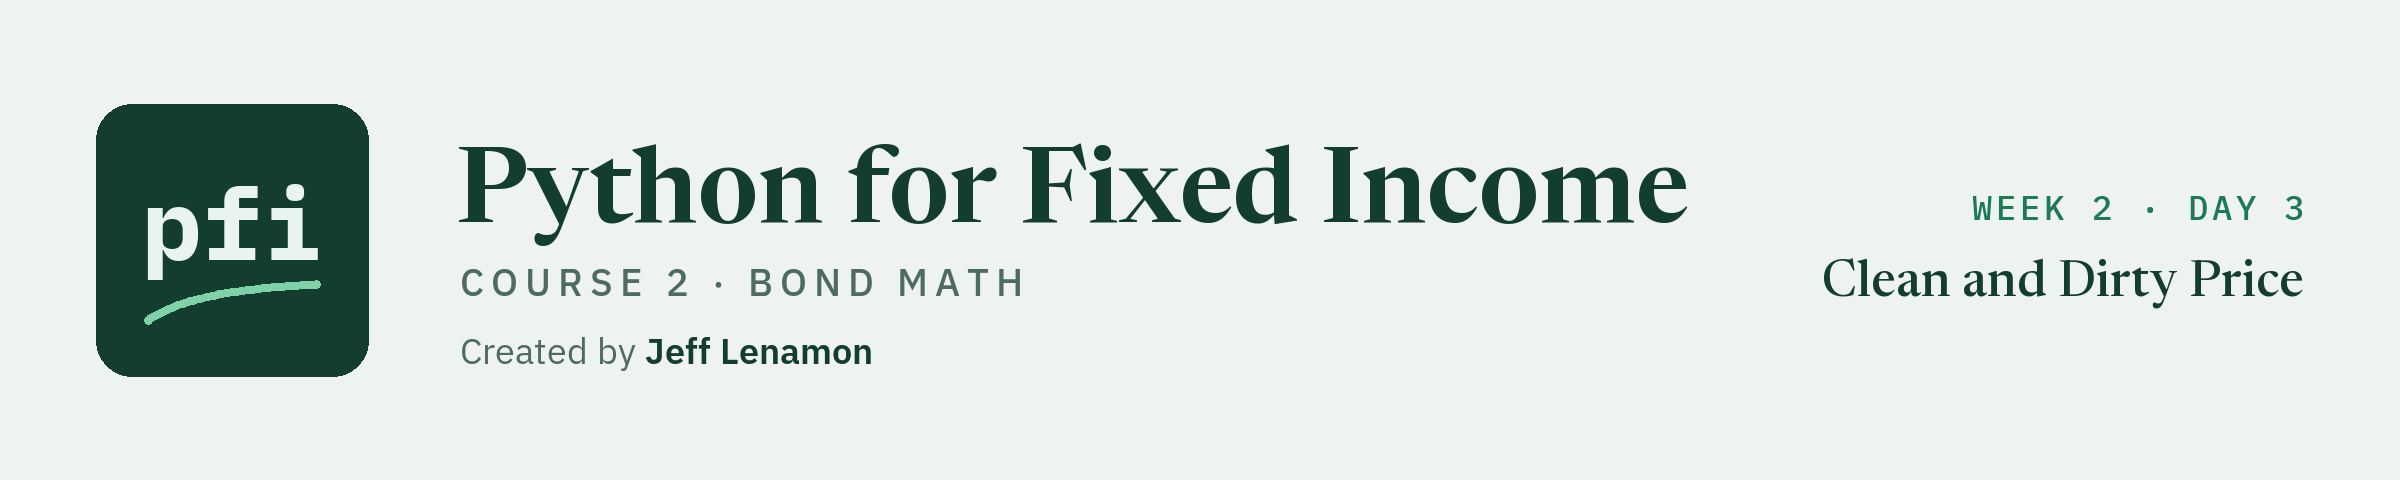

# Clean and Dirty Price

Week 2, Day 3. Price a bond between coupons: the quote is the clean price, the invoice adds accrued interest, and the cash flows are discounted from settlement over part of a period. Then the yield from a clean price, both checked against Excel's PRICE and YIELD.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course2_bond_math/week2/day3/08_clean_and_dirty_price.ipynb)

Day 7 answered the first money question of week 2: on Monday 30 November 2026, Quorvane has accrued 0.875 per 100 of face, interest earned since the previous coupon on 30 September. Today answers the second: **what is the bond worth on that date, and what does the buyer pay?**

The desk's question: you buy 1,000,000 dollars of face of Quorvane Energy at its issue yield, 5.40 percent, settling 30 November 2026. What price is quoted, and how much cash leaves the account?

Week 1 priced bonds on a coupon date, where the next coupon was exactly one period away and nothing had accrued. On 30 November the next coupon is four months away, not six, and two months of interest belong to the seller. Two things change, and today handles both.

Today you will:

1. Tell the quote from the invoice: the clean price, and the dirty price the buyer pays.
2. Discount from settlement over part of a period, w = DSC / E.
3. Add `price` and `dirty_price` to your module, checked against Excel's `PRICE`.
4. Check that on a coupon date `price` gives week 1's answer.
5. Price the final coupon period with simple interest, as Excel does.
6. Add `yield_to_maturity`, checked against Excel's `YIELD`.
7. Compute accrued interest and the invoice amount of every trade in the September trade blotter.

The issuers are invented, and so is every number. Nothing here says a bond, an issuer, or a trade is good or bad.

The setup cell is the same as every day. Then the next cell writes `bondmath.py` and `test_bondmath.py` as they stood at the end of day 7.

Q. Set up today's work folder and copy the Excel reference files into it.

In [1]:
# modules that come with Python: folders and files, the temp folder, running programs, reloading a module
import importlib
import os
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

import pandas as pd

# pytest runs the tests. A Colab runtime may not have it.
try:
    import pytest
except ImportError:
    raise RuntimeError("pytest is not installed. Run  !pip install pytest  in a new cell, then run this cell again.") from None

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "bondmath_excel_reference.csv").exists()
data_folder = RAW_DATA if on_github else str(local_data) + os.sep

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course2_08_"))
os.chdir(work)

# 3. copy the two Excel reference files into the work folder
for name in ["bondmath_excel_reference.csv", "bondmath_excel_reference_tvm.csv"]:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Reference files copied from: {'GitHub' if on_github else 'the data folder of the course repo'}")
print(f"pytest version: {pytest.__version__}")

Work folder: pfi_course2_08_t4zlbqvl, in your temp folder
Reference files copied from: the data folder of the course repo
pytest version: 9.1.1


Q. Write `bondmath.py` and `test_bondmath.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [2]:
%%writefile bondmath.py
"""bondmath: bond math for fixed-rate bullet bonds, checked against Excel.

Written day by day in Python for Fixed Income, Course 2: Bond Math.

Units, the same in every function:
- coupon_pct and yield_pct are annual rates in percent: 7.0 means 7 percent. Excel takes decimals (0.07).
- Prices and accrued interest are per 100 of face.
- Durations are in years, convexity in years squared, spreads in basis points.
- frequency is the number of coupons (or compounding periods) a year: 1, 2, or 4.
- basis is the day count: "30/360" (Excel basis 0) or "ACT/ACT" (Excel basis 1).
- Dates are datetime.date values.
"""
import calendar  # month lengths, used from week 2
from datetime import date  # calendar dates, used from week 2


def future_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Grow an amount at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount x (1 + rate / frequency) ** (frequency x years).
    Excel: =FV(rate_pct/100/frequency, frequency*years, 0, -amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # grow the amount over every period
    return amount * (1 + period_rate) ** periods


def present_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Discount an amount due in `years` at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount / (1 + rate / frequency) ** (frequency x years).
    Returns a positive number for a positive amount. Excel's PV returns the same number with a
    minus sign: =-PV(rate_pct/100/frequency, frequency*years, 0, amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # discount the amount over every period
    return amount / (1 + period_rate) ** periods


def cash_flows(coupon_pct: float, years: float, frequency: int = 2) -> list[tuple[float, float]]:
    """The cash flows of a bullet bond bought on a coupon date.

    Units: coupon_pct in percent of face a year, years in years. Each cash flow is per 100 of face.
    Convention: one coupon of coupon_pct / frequency every 1 / frequency years, and 100 back with
    the last coupon. Returns a list of (time in years, cash flow) pairs, earliest first.
    Raises ValueError unless years x frequency is a whole number of periods.
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # count the coupon periods and check they are whole
    periods = years * frequency
    if periods <= 0 or abs(periods - round(periods)) > 1e-9:
        raise ValueError(f"{years} years is not a whole number of periods at frequency {frequency}")
    periods = round(periods)
    # each coupon is the annual coupon split into equal parts
    coupon = coupon_pct / frequency
    flows = []
    for k in range(1, periods + 1):
        # the time of payment k, in years
        time_years = k / frequency
        # the last payment also returns the face of 100
        amount = coupon + 100 if k == periods else coupon
        flows.append((time_years, amount))
    return flows


def price_from_yield(coupon_pct: float, yield_pct: float, years: float, frequency: int = 2) -> float:
    """Price of a bullet bond on a coupon date, from its yield.

    Units: coupon_pct and yield_pct in percent a year, years in years, price per 100 of face.
    Convention: each cash flow is discounted at yield_pct compounded `frequency` times a year.
    On a coupon date there is no accrued interest, so this is both the clean and the dirty price.
    Excel: =-PV(yield_pct/100/frequency, frequency*years, coupon_pct/frequency, 100)
    """
    # the yield for one period, as a decimal
    period_yield = yield_pct / 100 / frequency
    price = 0.0
    for time_years, amount in cash_flows(coupon_pct, years, frequency):
        # discount each cash flow by one factor per period until it is paid
        price += amount / (1 + period_yield) ** (time_years * frequency)
    return price


def convert_yield(yield_pct: float, from_frequency: int, to_frequency: int) -> float:
    """The same yield restated at another compounding frequency.

    Units: yield_pct in percent a year; the result is in percent a year.
    Convention: both rates grow 100 to the same amount in one year.
    Excel: convert_yield(y, f, 1) is =EFFECT(y/100, f)*100, and convert_yield(y, 1, f) is =NOMINAL(y/100, f)*100.
    """
    # stop on a frequency the course does not use
    for frequency in (from_frequency, to_frequency):
        if frequency not in (1, 2, 4):
            raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # how much 1 grows to in one year at the original frequency
    growth_one_year = (1 + yield_pct / 100 / from_frequency) ** from_frequency
    # the rate per period at the new frequency that gives the same growth
    period_rate = growth_one_year ** (1 / to_frequency) - 1
    # back to an annual rate in percent
    return period_rate * to_frequency * 100


def yield_from_price(coupon_pct: float, price: float, years: float, frequency: int = 2) -> float:
    """Yield of a bullet bond on a coupon date, from its price, by bisection.

    Units: coupon_pct in percent a year, price per 100 of face, years in years; the result is in percent.
    Convention: the yield, compounded `frequency` times a year, at which price_from_yield equals price.
    The search runs between -5 and 100 percent and stops when the bracket is narrower than 1e-10 percent.
    Raises ValueError if the price is outside the prices at those two yields.
    Excel: =RATE(frequency*years, coupon_pct/frequency, -price, 100)*frequency, then x 100.
    """
    # the bracket: price falls as yield rises, so the low yield gives the high price
    low_pct, high_pct = -5.0, 100.0
    highest_price = price_from_yield(coupon_pct, low_pct, years, frequency)
    lowest_price = price_from_yield(coupon_pct, high_pct, years, frequency)
    if not lowest_price <= price <= highest_price:
        raise ValueError(f"price {price} is outside {lowest_price:.6f} to {highest_price:.6f}, "
                         f"the prices at yields of {high_pct} and {low_pct} percent")
    # halve the bracket until it is narrow enough
    while high_pct - low_pct > 1e-10:
        mid_pct = (low_pct + high_pct) / 2
        if price_from_yield(coupon_pct, mid_pct, years, frequency) > price:
            # price too high at mid, so the yield is above mid
            low_pct = mid_pct
        else:
            # price too low (or equal) at mid, so the yield is at or below mid
            high_pct = mid_pct
    # the middle of the final bracket
    return (low_pct + high_pct) / 2


def add_months(d: date, months: int) -> date:
    """Move a date by whole months, keeping the day of the month where the month allows it.

    Units: d is a date, months a whole number (negative moves back).
    Convention: the day is clamped to the length of the new month, so 31 August minus 6 months is
    28 February (29 February in a leap year). Excel: =EDATE(d, months)
    """
    # count months from year 0 so the year and month come out of one division
    month_index = d.year * 12 + (d.month - 1) + months
    year, month_zero_based = divmod(month_index, 12)
    month = month_zero_based + 1
    # the number of days in the new month
    days_in_month = calendar.monthrange(year, month)[1]
    # keep the day, or use the last day of a shorter month
    return date(year, month, min(d.day, days_in_month))


def coupon_dates(settlement: date, maturity: date, frequency: int = 2) -> list[date]:
    """The previous coupon date, then every coupon date left through maturity.

    Units: dates. Convention: coupon dates are counted back from maturity in steps of 12 / frequency
    months, each one computed from maturity directly, so a 31st never drifts to the 28th. If maturity
    is the last day of its month, every coupon date is the last day of its month (Excel's rule).
    The previous coupon date is the last one on or before settlement.
    So [0] is Excel's COUPPCD, [1] is COUPNCD, and len - 1 is COUPNUM.
    """
    # stop on bad input
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    if settlement >= maturity:
        raise ValueError(f"settlement {settlement} must be before maturity {maturity}")
    # months between coupons
    step_months = 12 // frequency
    # does the bond mature on the last day of a month?
    month_end = maturity.day == calendar.monthrange(maturity.year, maturity.month)[1]
    dates = []
    k = 0
    while True:
        # coupon k steps back from maturity, computed from maturity itself
        coupon_date = add_months(maturity, -k * step_months)
        if month_end:
            # the month-end rule: move to the last day of that month
            last_day = calendar.monthrange(coupon_date.year, coupon_date.month)[1]
            coupon_date = date(coupon_date.year, coupon_date.month, last_day)
        dates.append(coupon_date)
        # stop once we reach the previous coupon date
        if coupon_date <= settlement:
            break
        k += 1
    # earliest first
    dates.reverse()
    return dates


def days_30_360(start: date, end: date) -> int:
    """Days from start to end on the US 30/360 basis, as Excel's COUPDAYBS and YEARFRAC(..., 0) count them.

    Units: dates in, whole days out. Every month counts as 30 days and every year as 360.
    Convention, with D1 the start day and D2 the end day:
    1. If start is the last day of February, D1 = 30.
    2. If start and end are both the last day of February, D2 = 30.
    3. If D1 is 31, D1 = 30.
    4. If D2 is 31 and the start day was 30 or 31, D2 = 30. (Excel looks at the start date's own
       day here, so a start on 28 February and an end on the 31st keeps D2 = 31.)
    Days = 360 x (Y2 - Y1) + 30 x (M2 - M1) + (D2 - D1).
    Excel's DAYS360 uses different February rules and is not the same count.
    """
    d1, d2 = start.day, end.day
    start_is_feb_end = start.month == 2 and start.day == calendar.monthrange(start.year, 2)[1]
    end_is_feb_end = end.month == 2 and end.day == calendar.monthrange(end.year, 2)[1]
    # rule 1: the last day of February counts as the 30th
    if start_is_feb_end:
        d1 = 30
    # rule 2: both dates on the last day of February
    if start_is_feb_end and end_is_feb_end:
        d2 = 30
    # rule 3: a 31st start counts as the 30th
    if start.day == 31:
        d1 = 30
    # rule 4: a 31st end counts as the 30th when the start day was 30 or 31
    if end.day == 31 and start.day >= 30:
        d2 = 30
    return 360 * (end.year - start.year) + 30 * (end.month - start.month) + (d2 - d1)


def coupon_period_days(settlement: date, maturity: date, frequency: int = 2,
                       basis: str = "30/360") -> tuple[int, int, int]:
    """Day counts of the coupon period that holds settlement: (A, E, DSC).

    Units: whole days.
    A is days from the previous coupon to settlement (Excel COUPDAYBS).
    E is days in the coupon period: 360 / frequency under 30/360 (Excel COUPDAYS), and the actual days
    from the previous to the next coupon under ACT/ACT.
    DSC is days from settlement to the next coupon, as Excel's PRICE uses it: E - A under 30/360
    (this can differ from COUPDAYSNC near the end of February), actual days under ACT/ACT.
    """
    # stop on a basis the course does not use (coupon_dates checks frequency and dates)
    if basis not in ("30/360", "ACT/ACT"):
        raise ValueError(f'basis must be "30/360" or "ACT/ACT", not {basis!r}')
    # the previous and next coupon dates
    dates = coupon_dates(settlement, maturity, frequency)
    previous_coupon, next_coupon = dates[0], dates[1]
    if basis == "30/360":
        # 30/360: A by the 30/360 rules, a fixed period length, and DSC as what is left of it
        days_accrued = days_30_360(previous_coupon, settlement)
        days_in_period = 360 // frequency
        days_to_next = days_in_period - days_accrued
    else:
        # ACT/ACT: every count is actual calendar days
        days_accrued = (settlement - previous_coupon).days
        days_in_period = (next_coupon - previous_coupon).days
        days_to_next = (next_coupon - settlement).days
    return days_accrued, days_in_period, days_to_next


def accrued_interest(settlement: date, maturity: date, coupon_pct: float, frequency: int = 2,
                     basis: str = "30/360") -> float:
    """Accrued interest the buyer pays the seller, per 100 of face.

    Units: coupon_pct in percent a year; the result is per 100 of face.
    Convention: coupon_pct / frequency x A / E, with A and E from coupon_period_days.
    Excel (30/360): =100*coupon_pct/100/frequency*COUPDAYBS(...)/COUPDAYS(...)
    """
    # A and E for this settlement
    days_accrued, days_in_period, _ = coupon_period_days(settlement, maturity, frequency, basis)
    # one coupon, times the share of the period that has passed
    return coupon_pct / frequency * days_accrued / days_in_period

Writing bondmath.py


In [3]:
%%writefile test_bondmath.py
"""Tests for bondmath.py.

Every expected value comes from Excel: the two reference CSV files in this folder, or a small hand
table whose values those files confirm. Run from this folder with:  python -m pytest
"""
import csv
import math  # used from week 3
from datetime import date  # used from week 2
from pathlib import Path

import pytest

import bondmath

# the reference files sit in the same folder as this test file
HERE = Path(__file__).parent


def read_rows(file_name: str) -> list[dict]:
    """Read a reference CSV from this folder: one dict per row, every value a string."""
    with open(HERE / file_name, newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))


TVM = read_rows("bondmath_excel_reference_tvm.csv")


def tvm_rows(function: str) -> list[dict]:
    """The week 1 reference rows for one Excel function, for example "FV"."""
    rows = [row for row in TVM if row["function"] == function]
    assert rows, f"no {function} rows in the reference file"
    return rows


def test_future_value_matches_excel_fv():
    for row in tvm_rows("FV"):
        # the inputs, in course units
        amount, rate_pct = float(row["amount"]), float(row["rate_pct"])
        years, frequency = float(row["years"]), int(row["frequency"])
        result = bondmath.future_value(amount, rate_pct, years, frequency)
        # Excel's FV, with the amount entered as -amount, is positive
        assert result == pytest.approx(float(row["excel_value"]), abs=1e-6), row["case_id"]


def test_present_value_matches_excel_pv():
    for row in tvm_rows("PV"):
        amount, rate_pct = float(row["amount"]), float(row["rate_pct"])
        years, frequency = float(row["years"]), int(row["frequency"])
        result = bondmath.present_value(amount, rate_pct, years, frequency)
        # Excel's PV of a positive amount is negative (money paid now), so compare with minus the Excel value
        assert result == pytest.approx(-float(row["excel_value"]), abs=1e-6), row["case_id"]


def test_present_value_undoes_future_value():
    for frequency in (1, 2, 4):
        # grow 100 for 3 years at 5 percent, then discount it back
        grown = bondmath.future_value(100, 5.0, 3, frequency)
        assert bondmath.present_value(grown, 5.0, 3, frequency) == pytest.approx(100, abs=1e-9)


REFERENCE = read_rows("bondmath_excel_reference.csv")


def test_cash_flows_count_and_final_flow():
    flows = bondmath.cash_flows(6.0, 5, 2)
    # 5 years of half-year coupons is 10 cash flows
    assert len(flows) == 10
    # the first is a 3.00 coupon after half a year, the last is the coupon plus the face at 5 years
    assert flows[0] == pytest.approx((0.5, 3.0))
    assert flows[-1] == pytest.approx((5.0, 103.0))


def test_cash_flows_raises_on_part_periods():
    # 2.3 years is not a whole number of half years, so cash_flows must stop with a ValueError
    try:
        bondmath.cash_flows(6.0, 2.3, 2)
    except ValueError:
        return
    assert False, "cash_flows accepted 2.3 years at frequency 2"


def test_price_from_yield_matches_excel():
    # Excel's -PV with a coupon: a bond priced on a coupon date
    for row in tvm_rows("PV_BOND"):
        result = bondmath.price_from_yield(float(row["coupon_pct"]), float(row["rate_pct"]),
                                           float(row["years"]), int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]), abs=1e-6), row["case_id"]
    # Excel's PRICE on the rows that settle on a coupon date (no days accrued)
    coupon_date_rows = [row for row in REFERENCE if row["coupdaybs"] == "0"]
    assert coupon_date_rows, "no coupon-date rows in the reference file"
    for row in coupon_date_rows:
        frequency = int(row["frequency"])
        years = int(row["coupnum"]) / frequency
        result = bondmath.price_from_yield(float(row["coupon_pct"]), float(row["yield_pct"]), years, frequency)
        assert result == pytest.approx(float(row["price"]), abs=1e-6), row["case_id"]


def test_convert_yield_matches_excel_effect_and_nominal():
    # EFFECT restates a rate compounded `frequency` times a year as an annually compounded rate
    for row in tvm_rows("EFFECT"):
        result = bondmath.convert_yield(float(row["rate_pct"]), int(row["frequency"]), 1)
        # Excel returns a decimal, bondmath a percent
        assert result == pytest.approx(float(row["excel_value"]) * 100, abs=1e-9), row["case_id"]
    # NOMINAL goes the other way: from annual compounding to `frequency` times a year
    for row in tvm_rows("NOMINAL"):
        result = bondmath.convert_yield(float(row["rate_pct"]), 1, int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]) * 100, abs=1e-9), row["case_id"]


def test_convert_yield_round_trip():
    # semiannual to quarterly and back gives the yield we started with
    quarterly = bondmath.convert_yield(6.0, 2, 4)
    assert bondmath.convert_yield(quarterly, 4, 2) == pytest.approx(6.0, abs=1e-12)


def test_yield_from_price_matches_excel():
    # Excel's RATE, times the frequency, is the annual yield as a decimal
    for row in tvm_rows("RATE"):
        result = bondmath.yield_from_price(float(row["coupon_pct"]), float(row["price"]),
                                           float(row["years"]), int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]) * 100, abs=1e-6), row["case_id"]
    # Excel's YIELD on the coupon-date rows, already in percent in the reference file
    for row in REFERENCE:
        if row["coupdaybs"] != "0":
            continue
        frequency = int(row["frequency"])
        years = int(row["coupnum"]) / frequency
        result = bondmath.yield_from_price(float(row["coupon_pct"]), float(row["price"]), years, frequency)
        assert result == pytest.approx(float(row["yield_pct_from_price"]), abs=1e-6), row["case_id"]


def test_yield_raises_outside_bracket():
    # no yield between -5 and 100 percent gives a price of 1,000 or of 0.01
    with pytest.raises(ValueError):
        bondmath.yield_from_price(6.0, 1000.0, 5, 2)
    with pytest.raises(ValueError):
        bondmath.yield_from_price(6.0, 0.01, 5, 2)


def test_yield_round_trip():
    # price a bond from a yield, then solve the yield back from that price
    bond_price = bondmath.price_from_yield(5.25, 6.1, 7, 2)
    assert bondmath.yield_from_price(5.25, bond_price, 7, 2) == pytest.approx(6.1, abs=1e-8)


def test_par_bond_prices_at_100():
    # a coupon equal to the yield prices at 100 for every frequency and term
    for frequency in (1, 2, 4):
        for years in (1, 2, 5, 10, 30):
            assert bondmath.price_from_yield(5.5, 5.5, years, frequency) == pytest.approx(100, abs=1e-9)


def test_price_falls_as_yield_rises():
    # price a 10-year 6 percent bond at yields from 2 to 12 percent
    prices = [bondmath.price_from_yield(6.0, yield_pct, 10, 2) for yield_pct in (2, 4, 6, 8, 10, 12)]
    # every price is below the one before it
    for earlier, later in zip(prices, prices[1:]):
        assert later < earlier


def test_add_months_clamps_to_month_end():
    # 31 August back 6 months: 28 February, or 29 February in a leap year
    assert bondmath.add_months(date(2031, 8, 31), -6) == date(2031, 2, 28)
    assert bondmath.add_months(date(2032, 8, 31), -6) == date(2032, 2, 29)
    # 31 January forward 1 month
    assert bondmath.add_months(date(2027, 1, 31), 1) == date(2027, 2, 28)
    # a day every month has is kept, across a year end
    assert bondmath.add_months(date(2026, 11, 15), 3) == date(2027, 2, 15)


def test_coupon_dates_match_excel():
    for row in REFERENCE:
        settlement, maturity = date.fromisoformat(row["settlement"]), date.fromisoformat(row["maturity"])
        dates = bondmath.coupon_dates(settlement, maturity, int(row["frequency"]))
        # [0] is COUPPCD, [1] is COUPNCD, and the number of dates after [0] is COUPNUM
        assert dates[0] == date.fromisoformat(row["couppcd"]), row["case_id"]
        assert dates[1] == date.fromisoformat(row["coupncd"]), row["case_id"]
        assert len(dates) - 1 == int(row["coupnum"]), row["case_id"]


BASIS = {"0": "30/360", "1": "ACT/ACT"}  # Excel's basis number to bondmath's name


def bond_inputs(row: dict) -> tuple:
    """settlement, maturity, coupon_pct, yield_pct, frequency, basis from a reference row, in bondmath's units."""
    return (date.fromisoformat(row["settlement"]), date.fromisoformat(row["maturity"]),
            float(row["coupon_pct"]), float(row["yield_pct"]), int(row["frequency"]), BASIS[row["basis"]])


def test_days_30_360_rule_cases():
    # (start, end, expected days, the Excel function that confirms the value)
    cases = [
        (date(2026, 8, 16), date(2026, 9, 30), 44, "COUPDAYBS"),    # no rule applies
        (date(2027, 2, 28), date(2027, 3, 1), 1, "COUPDAYBS"),      # rule 1: last day of February counts as 30
        (date(2027, 2, 28), date(2028, 2, 29), 360, "YEARFRAC"),    # rule 2: both on the last day of February
        (date(2026, 8, 31), date(2026, 9, 30), 30, "COUPDAYBS"),    # rule 3: a 31st start counts as 30
        (date(2026, 7, 30), date(2026, 10, 31), 90, "COUPDAYBS"),   # rule 4: a 31st end after a 30th start
        (date(2026, 10, 15), date(2026, 10, 31), 16, "COUPDAYBS"),  # a 31st end after a 15th start stays 31
        (date(2027, 2, 28), date(2027, 3, 31), 31, "COUPDAYBS"),    # rule 1, and the 31st end stays 31
        (date(2026, 11, 15), date(2027, 2, 28), 103, "COUPDAYBS"),  # an end on 28 February is not changed
    ]
    for start, end, expected, source in cases:
        assert bondmath.days_30_360(start, end) == expected, (start, end)
        if source == "COUPDAYBS":
            # the same pair of dates appears in the reference file as previous coupon and settlement
            matches = [row for row in REFERENCE if row["basis"] == "0" and row["couppcd"] == start.isoformat()
                       and row["settlement"] == end.isoformat()]
            assert matches, f"no reference row with previous coupon {start} and settlement {end}"
            assert int(matches[0]["coupdaybs"]) == expected
        # the YEARFRAC value, YEARFRAC(start, end, 0) x 360 = 360, was checked in Excel by the reference tool


def test_coupon_period_days_match_excel():
    for row in REFERENCE:
        settlement, maturity, _, _, frequency, basis = bond_inputs(row)
        days_accrued, days_in_period, days_to_next = bondmath.coupon_period_days(settlement, maturity, frequency, basis)
        # A is COUPDAYBS under both bases
        assert days_accrued == int(row["coupdaybs"]), row["case_id"]
        if basis == "30/360":
            # E is COUPDAYS, and PRICE uses DSC = E - A
            assert days_in_period == int(row["coupdays"]), row["case_id"]
            assert days_to_next == int(row["coupdays"]) - int(row["coupdaybs"]), row["case_id"]
        else:
            # E is the actual length of the period, which PRICE uses (Excel's COUPDAYS with basis 1 can differ)
            period_start, period_end = date.fromisoformat(row["couppcd"]), date.fromisoformat(row["coupncd"])
            assert days_in_period == (period_end - period_start).days, row["case_id"]
            assert days_to_next == int(row["coupdaysnc"]), row["case_id"]


def test_accrued_matches_excel():
    for row in REFERENCE:
        settlement, maturity, coupon_pct, _, frequency, basis = bond_inputs(row)
        result = bondmath.accrued_interest(settlement, maturity, coupon_pct, frequency, basis)
        assert result == pytest.approx(float(row["accrued"]), abs=1e-9), row["case_id"]

Writing test_bondmath.py


Q. Import the module.

In [4]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import bondmath

# reload reads the file again, so that running this cell after a change picks up the change
importlib.reload(bondmath)

# the functions defined in the module itself, not the ones it imports
functions = [name for name, obj in vars(bondmath).items() if callable(obj) and getattr(obj, "__module__", "") == "bondmath"]
print(f"bondmath functions: {functions}")

bondmath functions: ['future_value', 'present_value', 'cash_flows', 'price_from_yield', 'convert_yield', 'yield_from_price', 'add_months', 'coupon_dates', 'days_30_360', 'coupon_period_days', 'accrued_interest']


* The two files exactly as day 7 left them: 11 functions and 18 tests. By the end of today there will be 14.

Record the starting point in Git first, as every day since day 2.

Q. Make the work folder a repository and commit the start-of-day files.

In [5]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [6]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course2_08_t4zlbqvl and nowhere else


In [7]:
# choose the two files, commit them quietly, and show the history
!git -C "{work}" add bondmath.py test_bondmath.py
!git -C "{work}" commit -q -m "Start of day 8: bondmath.py and test_bondmath.py as day 7 left them"
!git -C "{work}" log --oneline

d468249 Start of day 8: bondmath.py and test_bondmath.py as day 7 left them


* One commit, the start of day 8. Its hash changes on every run.

Q. Type in the four bonds, with their maturities as dates and their issue yields.

In [8]:
from datetime import date, timedelta

bonds = pd.DataFrame({
    "cusip": ['99001BZA7', '99002CZA4', '99003DZA1', '99004EZA8'],
    "issuer": ['Quorvane Energy', 'Dunmarrow Rail', 'Pellwick Paper', 'Halvering Foods'],
    "ticker": ['QVNE', 'DNMR', 'PLWK', 'HLVF'],
    "coupon_pct": [5.25, 6.125, 4.75, 7.5],
    "maturity": [date(2031, 9, 30), date(2033, 9, 30), date(2029, 9, 30), date(2036, 9, 30)],
    # the issue yield, percent a year: week 2 settles every bond at it
    "yield_pct": [5.4, 6.125, 4.6, 7.7],
})

# every week 2 bond settles on 30 November 2026
settlement = date(2026, 11, 30)
quorvane_maturity = date(2031, 9, 30)
bonds

,cusip,issuer,ticker,coupon_pct,maturity,yield_pct
0,99001BZA7,Quorvane Energy,QVNE,5.250,2031-09-30,5.400
1,99002CZA4,Dunmarrow Rail,DNMR,6.125,2033-09-30,6.125
2,99003DZA1,Pellwick Paper,PLWK,4.750,2029-09-30,4.600
3,99004EZA8,Halvering Foods,HLVF,7.500,2036-09-30,7.700


* The same four bonds, settled on the same day as days 6 and 7, at the yields they were issued at in week 1.

## 8.1 The Quote and the Invoice

A bond is quoted at its **clean price**: the price per 100 of face without accrued interest. The buyer pays the clean price **plus** the accrued interest. That total is the **dirty price**, also called the full price or the invoice price.

Q. How much interest has Quorvane accrued on 30 November? Day 7's function knows.

In [9]:
# day 7: one coupon times A / E, per 100 of face
quorvane_accrued = bondmath.accrued_interest(settlement, quorvane_maturity, 5.25)
print(f"Quorvane's accrued interest on {settlement}: {quorvane_accrued:.6f} per 100 of face")

Quorvane's accrued interest on 2026-11-30: 0.875000 per 100 of face


* 0.875 per 100: 60 of 180 days of a 2.625 coupon.

Q. Excel's reference file has Quorvane's clean price at 5.40 percent on 30 November, from Excel's `PRICE`. What does the buyer pay per 100, and in dollars on 1,000,000 of face?

In [10]:
reference = pd.read_csv("bondmath_excel_reference.csv")
# the week 2 rows: the week 1 bonds settled on 30 November 2026, case_id the CUSIP
week2 = reference[reference["group"] == "week2"].set_index("case_id")
excel_clean = week2.loc["99001BZA7", "price"]

face_dollars = 1_000_000
# the invoice: the clean price plus accrued interest, applied to the face
dirty = excel_clean + quorvane_accrued
print(f"Clean price (the quote): {excel_clean:.6f} per 100")
print(f"Accrued interest:        {quorvane_accrued:.6f} per 100")
print(f"Dirty price (invoice):   {dirty:.6f} per 100")
print()
print(f"Principal: {face_dollars * excel_clean / 100:>14,.2f} dollars")
print(f"Accrued:   {face_dollars * quorvane_accrued / 100:>14,.2f} dollars")
print(f"Invoice:   {face_dollars * dirty / 100:>14,.2f} dollars")

Clean price (the quote): 99.361551 per 100
Accrued interest:        0.875000 per 100
Dirty price (invoice):   100.236551 per 100

Principal:     993,615.51 dollars
Accrued:         8,750.00 dollars
Invoice:     1,002,365.51 dollars


* The quote is 99.361551. The cash that leaves the account is 1,002,365.51 dollars: 993,615.51 of principal and 8,750.00 of accrued interest, which goes to the seller for the two months they held the bond.
* The trade ticket shows the clean price. Settlement moves the dirty amount. Both are right; they answer different questions.

**Excel side by side: `PRICE` and the invoice.** Excel's `PRICE` returns the clean price. Tested in Excel: `=PRICE(DATE(2026,11,30),DATE(2031,9,30),5.25/100,5.4/100,100,2,0)` returns 99.36155142589135, the number in the reference file. The arguments are settlement, maturity, the coupon as a decimal, the yield as a decimal, the redemption (100), the frequency, and the basis (0 for 30/360). For the invoice, add day 7's accrued formula in the same cell: `=PRICE(DATE(2026,11,30),DATE(2031,9,30),5.25/100,5.4/100,100,2,0)+100*5.25/100/2*COUPDAYBS(DATE(2026,11,30),DATE(2031,9,30),2,0)/COUPDAYS(DATE(2026,11,30),DATE(2031,9,30),2,0)` returns 100.23655142589135.

Where does 99.361551 come from? Week 1 priced Quorvane at the same yield on its issue date at 99.350327. The next two sections build the price between coupons.

## 8.2 The Fractional First Period, w = DSC / E

On a coupon date the next coupon is one full period away, the one after two periods, and so on. Between coupons the next coupon is only **part** of a period away. That part is

w = DSC / E

where DSC is the days from settlement to the next coupon and E is the days in the coupon period, both from day 7's `coupon_period_days`. The next coupon is discounted over w periods, the one after over w + 1, and so on: every cash flow moves closer by the same amount.

Q. What are A, E, DSC, and w for Quorvane on 30 November?

In [11]:
days_accrued, days_in_period, days_to_next = bondmath.coupon_period_days(settlement, quorvane_maturity)
w = days_to_next / days_in_period
print(f"A = {days_accrued}, E = {days_in_period}, DSC = {days_to_next}")
print(f"w = DSC / E = {w:.6f} of a period to the next coupon")

A = 60, E = 180, DSC = 120
w = DSC / E = 0.666667 of a period to the next coupon


* 60 days have passed and 120 are left of a 180-day period, so the next coupon is w = 0.666667 of a period away: four months of six.
* Under 30/360, DSC is E - A, as Excel's `PRICE` uses it (day 7).

Q. Build Quorvane's cash flows as a table: each coupon date, its number of periods from settlement (w + k), the cash flow, the discount factor, and the present value. Their sum is the dirty price.

In [12]:
dates = bondmath.coupon_dates(settlement, quorvane_maturity)
coupons_left = len(dates) - 1
period_yield = 5.40 / 100 / 2

rows = []
for k in range(coupons_left):
    # a coupon of 5.25 / 2 every half year, and the face with the last one
    cash_flow = 5.25 / 2 + (100 if k == coupons_left - 1 else 0)
    periods = w + k
    discount_factor = 1 / (1 + period_yield) ** periods
    rows.append({"coupon_date": dates[k + 1], "periods": periods, "cash_flow": cash_flow,
                 "discount_factor": discount_factor, "present_value": cash_flow * discount_factor})

flows = pd.DataFrame(rows)
flows

,coupon_date,periods,cash_flow,discount_factor,present_value
0,2027-03-31,0.666667,2.625,0.982396,2.578788
1,2027-09-30,1.666667,2.625,0.956568,2.510991
2,2028-03-31,2.666667,2.625,0.931420,2.444977
3,2028-09-30,3.666667,2.625,0.906933,2.380698
4,2029-03-31,4.666667,2.625,0.883089,2.318109
5,2029-09-30,5.666667,2.625,0.859873,2.257166
6,2030-03-31,6.666667,2.625,0.837266,2.197825
7,2030-09-30,7.666667,2.625,0.815255,2.140043
8,2031-03-31,8.666667,2.625,0.793821,2.083781
9,2031-09-30,9.666667,102.625,0.772952,79.324172


* The first coupon, on 31 March 2027, is 0.667 of a period away; the last, with the face, 9.667 periods away. Every row is week 1's discounting with w + k in place of a whole number of periods.

Q. Add up the present values, and take off the accrued interest. Does the result match Excel's `PRICE`?

In [13]:
dirty_by_hand = flows["present_value"].sum()
clean_by_hand = dirty_by_hand - quorvane_accrued

print(f"Dirty price, the sum:       {dirty_by_hand:.10f}")
print(f"Clean price, less accrued:  {clean_by_hand:.10f}")
print(f"Excel's PRICE:              {excel_clean:.10f}")
assert abs(clean_by_hand - excel_clean) < 1e-9

Dirty price, the sum:       100.2365514259
Clean price, less accrued:  99.3615514259
Excel's PRICE:              99.3615514259


* The sum of the discounted cash flows is the **dirty** price, 100.236551: what the cash flows are worth on the settlement date. Take off the accrued interest and you have the **clean** price, Excel's `PRICE` to the tenth decimal and beyond.
* So the market discounts first and subtracts accrued second. The dirty price is the economic value; the clean price is the dirty price with the seller's share taken out.

**Excel side by side: the price written out.** The same table in a sheet, tested in Excel. `=COUPDAYBS(DATE(2026,11,30),DATE(2031,9,30),2,0)` in B1 returns 60, `=COUPDAYS(DATE(2026,11,30),DATE(2031,9,30),2,0)` in B2 returns 180, `=COUPNUM(DATE(2026,11,30),DATE(2031,9,30),2,0)` in B3 returns 10, and `=(B2-B1)/B2` in B4 is w. Type 0 to 9 in A6:A15 for k, then in B6 `=IF(A6=$B$3-1,5.25/2+100,5.25/2)/(1+5.4/100/2)^($B$4+A6)` and fill it down: each cell is one discounted cash flow, and the `IF` adds the face to the last one. `=SUM(B6:B15)` in B16 returns 100.23655142589136, the dirty price, and `=B16-100*5.25/100/2*B1/B2` in B17 returns 99.36155142589136, beside `PRICE` at 99.36155142589135, 1e-14 apart.

Q. There is a shortcut that reuses week 1. Price the bond as if settlement were a coupon date, with all 10 coupons a whole number of periods away, then move that value forward to settlement by A / E of a period.

In [14]:
# week 1's price puts the next coupon one whole period away; it is really w away,
# so every cash flow is (1 - w) = A / E of a period closer: grow the week 1 price by that much
week1_style = bondmath.price_from_yield(5.25, 5.40, coupons_left / 2)
shifted = week1_style * (1 + period_yield) ** (days_accrued / days_in_period)
print(f"Week 1 price with 10 whole periods: {week1_style:.6f}")
print(f"Moved forward by A / E of a period: {shifted:.6f}, the dirty price")

Week 1 price with 10 whole periods: 99.350327
Moved forward by A / E of a period: 100.236551, the dirty price


* 100.236551, the dirty price again. Discounting each cash flow over w + k periods is the same as discounting over k + 1 periods, as week 1 did, and then growing the total by 1 - w = A / E of a period.

**Excel side by side: the dirty price in one cell.** Tested in Excel: `=-PV(5.4/100/2,COUPNUM(DATE(2026,11,30),DATE(2031,9,30),2,0),5.25/2,100)*(1+5.4/100/2)^(COUPDAYBS(DATE(2026,11,30),DATE(2031,9,30),2,0)/COUPDAYS(DATE(2026,11,30),DATE(2031,9,30),2,0))` returns 100.23655142589129. `-PV` is week 1's price of 10 whole periods, and the power moves it forward by A / E. It agrees with the column above to 7e-14.

## 8.3 `price` and `dirty_price`

Now the module. `price` takes the arguments of Excel's `PRICE` in Excel's order, without the redemption, which is always 100 in this course, and returns the clean price. `dirty_price` is the one-line wrapper that adds accrued interest back.

Q. Add `price` and `dirty_price` to the end of `bondmath.py`. Read them before you run the cell.

In [15]:
%%writefile -a bondmath.py


def price(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
          basis: str = "30/360") -> float:
    """Clean price per 100 of face on any settlement date, as Excel's PRICE.

    Units: coupon_pct and yield_pct in percent a year; the result is a clean price per 100 of face.
    Convention: yield compounded `frequency` times a year. w = DSC / E is the part of a period left
    until the next coupon. Dirty price = sum over the N coupons left of CF_k / (1 + y/f) ** (w + k).
    In the final coupon period (N = 1) Excel uses simple interest: dirty = (100 + CF) / (1 + w x y/f).
    Clean = dirty - accrued interest.
    Excel: =PRICE(settlement, maturity, coupon_pct/100, yield_pct/100, 100, frequency, basis)
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    days_accrued, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    # coupons left, the fraction of a period to the next one, the period yield, and one coupon
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    if coupons_left == 1:
        # final period: simple interest on the last coupon and the face
        dirty = (100 + coupon) / (1 + w * period_yield)
    else:
        dirty = 0.0
        for k in range(coupons_left):
            # the last cash flow also returns the face
            cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
            dirty += cash_flow / (1 + period_yield) ** (w + k)
    # the quote is clean: take off the accrued interest
    return dirty - accrued_interest(settlement, maturity, coupon_pct, frequency, basis)


def dirty_price(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                basis: str = "30/360") -> float:
    """Dirty (full, invoice) price per 100 of face: the clean price plus accrued interest.

    Units and convention as price(). Excel: =PRICE(...) + the accrued formula.
    """
    # clean price plus accrued interest
    return (price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
            + accrued_interest(settlement, maturity, coupon_pct, frequency, basis))

Appending to bondmath.py


* `Appending to bondmath.py`. The docstring of `price` states the units (percent in, clean price per 100 out), the convention (compounding at the coupon frequency, w = DSC / E, the final period, clean = dirty - accrued), and the Excel formula with the `/100`.
* The code is section 8.2 in a function: the coupon dates and day counts, then the loop over w + k, then the accrued taken off at the end. The `if coupons_left == 1` branch is the final coupon period, section 8.5.
* `coupon_dates` and `coupon_period_days` check the frequency, the basis, and that settlement is before maturity, so `price` stops on bad input without checks of its own.
* `dirty_price` calls `price` and adds `accrued_interest`, so the clean and the dirty price can never disagree about the accrued.

Q. Reload the module, and price the four bonds at their issue yields against Excel.

In [16]:
importlib.reload(bondmath)

rows = []
for bond in bonds.itertuples():
    clean = bondmath.price(settlement, bond.maturity, bond.coupon_pct, bond.yield_pct)
    accrued = bondmath.accrued_interest(settlement, bond.maturity, bond.coupon_pct)
    rows.append({"issuer": bond.issuer, "clean": clean, "excel_price": week2.loc[bond.cusip, "price"],
                 "accrued": accrued, "dirty": bondmath.dirty_price(settlement, bond.maturity, bond.coupon_pct, bond.yield_pct)})

prices = pd.DataFrame(rows)
# the course's tolerance for a price against Excel: 1e-6 per 100
assert ((prices["clean"] - prices["excel_price"]).abs() < 1e-6).all()
assert ((prices["dirty"] - prices["clean"] - prices["accrued"]).abs() < 1e-12).all()
prices

,issuer,clean,excel_price,accrued,dirty
0,Quorvane Energy,99.361551,99.361551,0.875000,100.236551
1,Dunmarrow Rail,99.989753,99.989753,1.020833,101.010586
2,Pellwick Paper,100.388247,100.388247,0.791667,101.179914
3,Halvering Foods,98.622491,98.622491,1.250000,99.872491


* All four clean prices equal Excel's `PRICE`, and each dirty price is its clean price plus its accrued.
* Look at Dunmarrow. Its coupon equals its yield, 6.125 percent, so in week 1 it priced at exactly par. Between coupons its clean price is 99.989753, a little under 100. The cash flows are discounted with compound interest over the part period, while accrued interest grows in a straight line, so the two do not cancel exactly between coupon dates. On every coupon date the clean price of a par bond is 100 again.

Q. Why are bonds quoted clean? Chart Quorvane's clean and dirty price at the same 5.40 percent yield for every settlement date over a year.

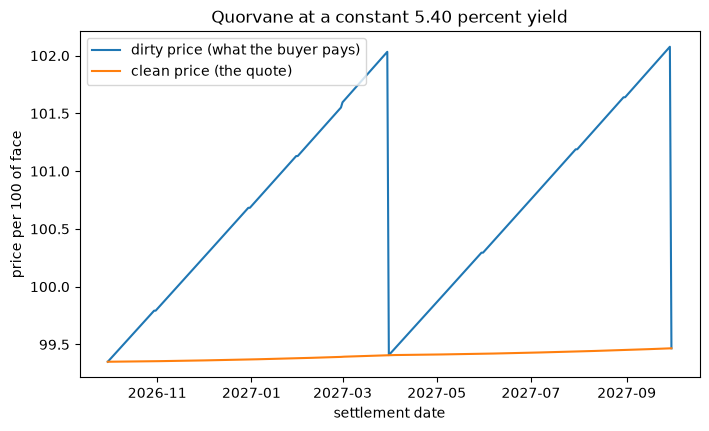

In [17]:
import matplotlib.pyplot as plt

# every settlement day from the issue date for a year, at the same yield
days = [date(2026, 9, 30) + timedelta(days=i) for i in range(366)]
clean_prices = [bondmath.price(d, quorvane_maturity, 5.25, 5.40) for d in days]
dirty_prices = [bondmath.dirty_price(d, quorvane_maturity, 5.25, 5.40) for d in days]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(days, dirty_prices, label="dirty price (what the buyer pays)")
ax.plot(days, clean_prices, label="clean price (the quote)")
ax.set_title("Quorvane at a constant 5.40 percent yield")
ax.set_xlabel("settlement date")
ax.set_ylabel("price per 100 of face")
ax.legend()
plt.show()

* The dirty price climbs as interest accrues, then drops by the coupon on each coupon date (31 March and 30 September), when the coupon is paid and accrued interest starts again from zero. From 30 to 31 March 2027 it falls by 2.625000, exactly one coupon of 2.625: under 30/360, 30 March already counts all 180 days of the period.
* The clean price moves smoothly, rising slowly towards 100 as the bond ages: the pull to par of week 1, now on every day. A change in the quote is a change in value, not in the coupon calendar. That is why the market quotes clean.

Q. Add the first two tests: `price` against Excel's `PRICE` on every row of the reference file, and the dirty price against `PRICE` plus Excel's accrued formula.

In [18]:
%%writefile -a test_bondmath.py


def test_price_matches_excel():
    for row in REFERENCE:
        result = bondmath.price(*bond_inputs(row))
        assert result == pytest.approx(float(row["price"]), abs=1e-6), row["case_id"]


def test_dirty_is_clean_plus_accrued():
    for row in REFERENCE:
        result = bondmath.dirty_price(*bond_inputs(row))
        # Excel's PRICE plus Excel's accrued formula
        assert result == pytest.approx(float(row["price"]) + float(row["accrued"]), abs=1e-6), row["case_id"]

Appending to test_bondmath.py


* `bond_inputs(row)`, written on day 7, turns a reference row into the six arguments in `bondmath`'s units, so each test is a short loop. Both tests use the course's price tolerance, 1e-6 per 100.

Q. Run the tests.

In [19]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

....................                                                     [100%]
20 passed in 0.18s



* `20 passed`: day 7's 18 and the two new ones, on every row of the reference file: the 200 holdings bonds, the edge cases, frequencies 1 and 4, actual/actual, and the week 2 rows.

## 8.4 On a Coupon Date It Equals Week 1

A new function should agree with the old one wherever both apply. On a coupon date nothing has accrued and the next coupon is one full period away, so `price` should give exactly week 1's `price_from_yield`.

Q. What are A, E, and DSC on the issue date, 30 September 2026?

In [20]:
print(f"(A, E, DSC) on 2026-09-30: {bondmath.coupon_period_days(date(2026, 9, 30), quorvane_maturity)}")

(A, E, DSC) on 2026-09-30: (0, 180, 180)


* A is 0 and DSC equals E, so w = 1: the next coupon is one whole period away, and no accrued interest is taken off. Section 8.2's formula becomes week 1's.

Q. Price the four bonds on their issue date with `price`, and with week 1's `price_from_yield`.

In [21]:
rows = []
for bond in bonds.itertuples():
    years = bond.maturity.year - 2026
    rows.append({"issuer": bond.issuer,
                 "price_on_issue_date": bondmath.price(date(2026, 9, 30), bond.maturity, bond.coupon_pct, bond.yield_pct),
                 "week1_price_from_yield": bondmath.price_from_yield(bond.coupon_pct, bond.yield_pct, years)})

coupon_date = pd.DataFrame(rows)
assert ((coupon_date["price_on_issue_date"] - coupon_date["week1_price_from_yield"]).abs() < 1e-9).all()
coupon_date

,issuer,price_on_issue_date,week1_price_from_yield
0,Quorvane Energy,99.350327,99.350327
1,Dunmarrow Rail,100.000000,100.000000
2,Pellwick Paper,100.415887,100.415887
3,Halvering Foods,98.622736,98.622736


* The same four prices as week 1, to the twelfth decimal. Quorvane is 99.350327; Excel's week 1 formula `=-PV(5.4/100/2,2*5,5.25/2,100)` returned 99.35032727691537.
* The new function contains the old one as a special case. That is the check to make whenever a function is generalised: the old answers must not move.

Q. Add the test: on every reference row that settles on a coupon date, `price` equals `price_from_yield`.

In [22]:
%%writefile -a test_bondmath.py


def test_price_on_coupon_date_equals_week1():
    for row in REFERENCE:
        if row["coupdaybs"] != "0":
            continue
        settlement, maturity, coupon_pct, yield_pct, frequency, basis = bond_inputs(row)
        # on a coupon date the bond has a whole number of periods left
        years = int(row["coupnum"]) / frequency
        week1_price = bondmath.price_from_yield(coupon_pct, yield_pct, years, frequency)
        assert bondmath.price(settlement, maturity, coupon_pct, yield_pct, frequency, basis) == pytest.approx(
            week1_price, abs=1e-9), row["case_id"]

Appending to test_bondmath.py


* The test picks the rows with `COUPDAYBS` equal to 0, settlement on a coupon date, across both bases and all three frequencies, and compares the two functions to 1e-9. On a coupon date the years left are the coupons left over the frequency.

## 8.5 The Final Coupon Period and Simple Interest

When only one coupon is left, the bond is a single payment of the face plus the last coupon. For that period Excel's `PRICE` uses **simple** interest:

dirty = (100 + coupon / f) / (1 + w x y / f)

with y the yield as a decimal and f the frequency. Every other period compounds. `bondmath` follows Excel, which is why `price` has the `if coupons_left == 1` branch. None of the four week 2 bonds is in its final period, so take a row of the reference file that is: `edge_final_period`, a 5.0 percent coupon at a 6.0 percent yield, settled 30 September 2026, maturing 15 February 2027.

Q. Price it with `price`, and with the compound formula by hand.

In [23]:
final_settlement, final_maturity = date(2026, 9, 30), date(2027, 2, 15)
final_row = reference.set_index("case_id").loc["edge_final_period"]

a, e, dsc = bondmath.coupon_period_days(final_settlement, final_maturity)
w_final = dsc / e
accrued_final = bondmath.accrued_interest(final_settlement, final_maturity, 5.0)
print(f"coupons left: {len(bondmath.coupon_dates(final_settlement, final_maturity)) - 1}, A = {a}, DSC = {dsc}, w = {w_final}")

# simple interest over the part period, as Excel's PRICE does
simple = bondmath.price(final_settlement, final_maturity, 5.0, 6.0)
# compound interest over the same part period, for comparison
compound = (100 + 5.0 / 2) / (1 + 6.0 / 100 / 2) ** w_final - accrued_final

print(f"price, simple interest:   {simple:.10f}")
print(f"Excel's PRICE:            {final_row['price']:.10f}")
print(f"compound, for comparison: {compound:.10f}")

coupons left: 1, A = 45, DSC = 135, w = 0.75
price, simple interest:   99.6194987775
Excel's PRICE:            99.6194987775
compound, for comparison: 99.6276697643


* One coupon left, w = 0.75. `price` returns 99.61949877750611, equal to Excel's `PRICE` to the last digit.
* The compound formula gives 99.627670, 0.008171 more per 100, 81.71 dollars on 1,000,000 of face. Both are reasonable ways to discount a single payment; the convention decides. Excel's `PRICE` uses simple interest in the final period, tested on all 12 final-period rows of the reference file (both bases, frequencies 1, 2, and 4), and `bondmath` follows it.

**Excel side by side: the final period written out.** Tested in Excel: `=(100+5/2)/(1+(COUPDAYS(DATE(2026,9,30),DATE(2027,2,15),2,0)-COUPDAYBS(DATE(2026,9,30),DATE(2027,2,15),2,0))/COUPDAYS(DATE(2026,9,30),DATE(2027,2,15),2,0)*6/100/2)-100*5/100/2*COUPDAYBS(DATE(2026,9,30),DATE(2027,2,15),2,0)/COUPDAYS(DATE(2026,9,30),DATE(2027,2,15),2,0)` returns 99.61949877750611, equal to `=PRICE(DATE(2026,9,30),DATE(2027,2,15),5/100,6/100,100,2,0)`. The same with the power in place of the multiplication, `=(100+5/2)/(1+6/100/2)^((COUPDAYS(DATE(2026,9,30),DATE(2027,2,15),2,0)-COUPDAYBS(DATE(2026,9,30),DATE(2027,2,15),2,0))/COUPDAYS(DATE(2026,9,30),DATE(2027,2,15),2,0))-100*5/100/2*COUPDAYBS(DATE(2026,9,30),DATE(2027,2,15),2,0)/COUPDAYS(DATE(2026,9,30),DATE(2027,2,15),2,0)`, returns 99.62766976428897.

Q. Add the test: `price` against Excel on every final-period row.

In [24]:
%%writefile -a test_bondmath.py


def test_final_period_matches_excel():
    final_period_rows = [row for row in REFERENCE if row["coupnum"] == "1"]
    assert final_period_rows, "no final-period rows in the reference file"
    for row in final_period_rows:
        # one coupon left: Excel prices it with simple interest
        result = bondmath.price(*bond_inputs(row))
        assert result == pytest.approx(float(row["price"]), abs=1e-6), row["case_id"]

Appending to test_bondmath.py


* `test_price_matches_excel` already covers these rows. This test names the convention, so if the branch is ever broken the failure says where: in the final coupon period. The `assert final_period_rows` line stops the test from passing on an empty list if the reference file ever lost those rows.

## 8.6 `yield_to_maturity`

The last function of the day goes the other way: from a clean price to the yield, as Excel's `YIELD`. Outside the final period there is no formula, so it searches, with day 4's bisection on the new `price`.

Q. Add `yield_to_maturity` to the end of `bondmath.py`. Read it before you run the cell.

In [25]:
%%writefile -a bondmath.py


def yield_to_maturity(settlement: date, maturity: date, coupon_pct: float, clean_price: float,
                      frequency: int = 2, basis: str = "30/360") -> float:
    """Yield in percent from a clean price on any settlement date, by bisection, as Excel's YIELD x 100.

    Units: coupon_pct in percent a year, clean_price per 100 of face; the result is in percent a year.
    Convention: the yield at which price() equals clean_price. The search runs between -5 and 100
    percent and stops when the bracket is narrower than 1e-10 percent.
    Raises ValueError if the price is outside the prices at those two yields.
    Final coupon period: Excel's YIELD uses a formula instead of a search, with DSR, the days from
    settlement to maturity, counted by days_30_360 under 30/360 (actual days under ACT/ACT):
    yield = ((100 + CF) - dirty) / dirty x frequency x E / DSR. Under 30/360 DSR can differ from the
    E - A that PRICE uses, so in those cases YIELD does not return the yield PRICE was given.
    Excel: =YIELD(settlement, maturity, coupon_pct/100, clean_price, 100, frequency, basis)*100
    """
    # final coupon period: Excel's formula (coupon_dates and coupon_period_days check the inputs)
    if len(coupon_dates(settlement, maturity, frequency)) - 1 == 1:
        days_accrued, days_in_period, _ = coupon_period_days(settlement, maturity, frequency, basis)
        if basis == "30/360":
            days_to_maturity = days_30_360(settlement, maturity)
        else:
            days_to_maturity = (maturity - settlement).days
        coupon = coupon_pct / frequency
        # the dirty price paid, and what comes back at maturity
        paid = clean_price + coupon * days_accrued / days_in_period
        received = 100 + coupon
        # the simple return over the days left, made annual, in percent
        return (received - paid) / paid * frequency * days_in_period / days_to_maturity * 100
    # the bracket: price falls as yield rises, so the low yield gives the high price
    low_pct, high_pct = -5.0, 100.0
    highest_price = price(settlement, maturity, coupon_pct, low_pct, frequency, basis)
    lowest_price = price(settlement, maturity, coupon_pct, high_pct, frequency, basis)
    if not lowest_price <= clean_price <= highest_price:
        raise ValueError(f"price {clean_price} is outside {lowest_price:.6f} to {highest_price:.6f}, "
                         f"the prices at yields of {high_pct} and {low_pct} percent")
    # halve the bracket until it is narrow enough
    while high_pct - low_pct > 1e-10:
        mid_pct = (low_pct + high_pct) / 2
        if price(settlement, maturity, coupon_pct, mid_pct, frequency, basis) > clean_price:
            # price too high at mid, so the yield is above mid
            low_pct = mid_pct
        else:
            # price too low (or equal) at mid, so the yield is at or below mid
            high_pct = mid_pct
    # the middle of the final bracket
    return (low_pct + high_pct) / 2

Appending to bondmath.py


* The docstring states the units, the convention (the yield at which `price` equals the clean price), the bracket and when the search stops, the `ValueError`, the final-period formula, and the Excel route with `*100`.
* The loop is day 4's, line for line, with `price(settlement, maturity, ...)` in place of `price_from_yield(..., years, ...)`. Repeating ten clear lines is easier to read than a general solver.
* The final coupon period comes first, with a formula and no search: that is how Excel's `YIELD` works there. The next question shows what that means.

Q. Reload, and solve the yield of each bond from Excel's clean price. Do the issue yields come back?

In [26]:
importlib.reload(bondmath)

for bond in bonds.itertuples():
    excel_price = week2.loc[bond.cusip, "price"]
    solved = bondmath.yield_to_maturity(settlement, bond.maturity, bond.coupon_pct, excel_price)
    print(f"{bond.issuer:16} clean price {excel_price:.6f}: yield {solved:.8f} percent (issued at {bond.yield_pct})")

Quorvane Energy  clean price 99.361551: yield 5.40000000 percent (issued at 5.4)
Dunmarrow Rail   clean price 99.989753: yield 6.12500000 percent (issued at 6.125)
Pellwick Paper   clean price 100.388247: yield 4.60000000 percent (issued at 4.6)
Halvering Foods  clean price 98.622491: yield 7.70000000 percent (issued at 7.7)


* Each issue yield comes back to within 2e-11 percent: `yield_to_maturity` undoes `price`.

Q. Day 4 solved the yields of four quotes on the issue date: 99.125, 100.5, 100.875, and 97.75. Two months later, on 30 November, the same clean prices give what yields?

In [27]:
quotes = {"Quorvane Energy": 99.125, "Dunmarrow Rail": 100.5, "Pellwick Paper": 100.875, "Halvering Foods": 97.75}

for bond in bonds.itertuples():
    quote = quotes[bond.issuer]
    on_issue = bondmath.yield_to_maturity(date(2026, 9, 30), bond.maturity, bond.coupon_pct, quote)
    on_settlement = bondmath.yield_to_maturity(settlement, bond.maturity, bond.coupon_pct, quote)
    print(f"{bond.issuer:16} at {quote:7.3f}: {on_issue:.6f} percent on 2026-09-30, {on_settlement:.6f} percent on {settlement}")

Quorvane Energy  at  99.125: 5.452297 percent on 2026-09-30, 5.456532 percent on 2026-11-30
Dunmarrow Rail   at 100.500: 6.036364 percent on 2026-09-30, 6.032806 percent on 2026-11-30
Pellwick Paper   at 100.875: 4.435281 percent on 2026-09-30, 4.415878 percent on 2026-11-30
Halvering Foods  at  97.750: 7.828610 percent on 2026-09-30, 7.829977 percent on 2026-11-30


* The 30 September yields are day 4's. On 30 November each yield has moved away from the coupon: Quorvane, below par, from 5.452297 to 5.456532 percent; Pellwick, above par, from 4.435281 to 4.415878. The same discount, or premium, now has two months less in which to pull to par, so it is worth more yield per year.
* This describes what the formula does with an unchanged price. It says nothing about where any bond will trade.

**Excel side by side: `YIELD`.** Excel's `YIELD` takes the clean price, and returns the yield as a decimal, so multiply by 100 for percent. Tested in Excel: `=YIELD(DATE(2026,11,30),DATE(2031,9,30),5.25/100,99.125,100,2,0)*100` returns 5.456532360810871, and `yield_to_maturity` agrees with `YIELD` to within 5e-11 percent on all four quotes.

In the final coupon period `YIELD` uses a formula instead of a search: yield = ((100 + CF) - dirty) / dirty x f x E / DSR, where DSR is the days from settlement to maturity. Under 30/360 Excel counts DSR with the 30/360 rules, and that count can differ from the E - A that `PRICE` uses. When it does, `YIELD` does not return the yield `PRICE` was given. The reference file has such a row, `edge_final_period_month_end`: a 6.5 percent coupon priced at 5.0 percent, settled 15 December 2026, maturing 28 February 2027, the last day of February.

Q. Solve the yield of that row's price, and price it again at that yield.

In [28]:
month_end_row = reference.set_index("case_id").loc["edge_final_period_month_end"]
month_end_settlement, month_end_maturity = date(2026, 12, 15), date(2027, 2, 28)

solved = bondmath.yield_to_maturity(month_end_settlement, month_end_maturity, 6.5, month_end_row["price"])
print(f"PRICE at 5 percent:                {month_end_row['price']:.6f}")
print(f"Excel's YIELD of that price:       {month_end_row['yield_pct_from_price']:.6f} percent")
print(f"yield_to_maturity of that price:   {solved:.6f} percent")
print(f"price at that yield:               {bondmath.price(month_end_settlement, month_end_maturity, 6.5, solved):.6f}")

a, e, dsc = bondmath.coupon_period_days(month_end_settlement, month_end_maturity)
print(f"E - A, which PRICE uses:  {e - a} days")
print(f"DSR on 30/360, which YIELD uses: {bondmath.days_30_360(month_end_settlement, month_end_maturity)} days")

PRICE at 5 percent:                100.289734
Excel's YIELD of that price:       5.136986 percent
yield_to_maturity of that price:   5.136986 percent
price at that yield:               100.260880
E - A, which PRICE uses:  75 days
DSR on 30/360, which YIELD uses: 73 days


* Excel's `PRICE` at 5.0 percent gives 100.289734, and Excel's `YIELD` of that price is 5.136986 percent. `yield_to_maturity` returns the same, 5.136986, because it follows `YIELD`; and pricing at that yield gives 100.260880, not 100.289734.
* The reason is the day count. `PRICE` takes DSC as what is left of the 180-day period, E - A = 75 days. `YIELD` counts DSR from 15 December to 28 February directly on the 30/360 rules: two months and 13 days, 73 days, because an end date on 28 February is not moved to the 30th. 75 days and 73 days give two different yields for one price.
* Each function does exactly what it documents, and `bondmath` follows Excel in both. On a desk this matters only for a bond in its last coupon period near a month end; the course's data files hold none. Tested in Excel: `=YEARFRAC(DATE(2026,12,15),DATE(2027,2,28),0)*360` returns 73, and `=COUPDAYS(DATE(2026,12,15),DATE(2027,2,28),2,0)-COUPDAYBS(DATE(2026,12,15),DATE(2027,2,28),2,0)` returns 75.

Q. Add the last test: `yield_to_maturity` against Excel's `YIELD` on every row.

In [29]:
%%writefile -a test_bondmath.py


def test_yield_to_maturity_matches_excel():
    for row in REFERENCE:
        settlement, maturity, coupon_pct, _, frequency, basis = bond_inputs(row)
        # solve the yield from Excel's price, and compare with Excel's YIELD of that price
        result = bondmath.yield_to_maturity(settlement, maturity, coupon_pct, float(row["price"]), frequency, basis)
        assert result == pytest.approx(float(row["yield_pct_from_price"]), abs=1e-6), row["case_id"]

Appending to test_bondmath.py


* The reference file's `yield_pct_from_price` column is Excel's `YIELD` of Excel's `PRICE`, times 100. Comparing with that column, not with the yield the row was priced at, is what makes the test pass on `edge_final_period_month_end` too: it checks that `bondmath` returns what Excel returns.

Q. Run the tests.

In [30]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

.......................                                                  [100%]
23 passed in 1.20s



* `23 passed`: day 7's 18 and today's five.

## 8.7 Invoice Amounts for the September Trade Blotter

Course 1 looked at the desk's September trade blotter. Its `price` column is the clean price, and its `principal` column is face times the clean price: no accrued interest. The cash each trade settled for also included accrued interest at its `settle_date`. Today's functions can add it.

Q. Read `trade_blotter.csv` from the course data. Which columns are there?

In [31]:
blotter = pd.read_csv(data_folder + "trade_blotter.csv")
print(f"{len(blotter)} trades, settling {blotter['settle_date'].min()} to {blotter['settle_date'].max()}")
blotter.head()

374 trades, settling 2026-09-02 to 2026-10-01


,trade_id,trade_date,trade_time,settle_date,cusip,ticker,side,quantity,price,principal,counterparty,trader
0,T0001,2026-09-01,08:04,2026-09-02,99087JAG1,KRIX,BUY,500000,103.053,515265.00,Ulverthorne Markets,Desk 4
1,T0002,2026-09-01,09:10,2026-09-02,99003DAE0,PLWK,SELL,245000,95.434,233813.30,Talvesham Partners,Desk 2
2,T0003,2026-09-01,09:10,2026-09-02,99051ZAA0,TOVR,BUY,25000,97.875,24468.75,Zembrook Securities,Desk 1
3,T0004,2026-09-01,09:17,2026-09-02,99140KAG3,BRUH,BUY,750000,102.500,768750.00,Talvesham Partners,Desk 3
4,T0005,2026-09-01,10:05,2026-09-02,99010KAH8,THAN,BUY,65000,94.233,61251.45,Orlinthe Capital,Desk 1


* 374 trades. `quantity` is the face in dollars, `price` the clean price per 100, and `settle_date` the settlement date, one business day after the trade date. The blotter has no coupon or maturity: those are in `holdings.csv`, by CUSIP.

Q. Bring in each bond's coupon and maturity from the holdings file, and check that every trade found its bond.

In [32]:
holdings = pd.read_csv(data_folder + "holdings.csv")
# validate="many_to_one": many trades per bond, at most one holdings row per CUSIP
trades = blotter.merge(holdings[["cusip", "coupon", "maturity"]], on="cusip", how="left", validate="many_to_one")
assert len(trades) == len(blotter) and trades["coupon"].notna().all(), "a trade has no bond in the holdings file"

# principal is face x clean price / 100, to the cent
assert ((trades["quantity"] * trades["price"] / 100 - trades["principal"]).abs() < 0.005).all()
trades[["trade_id", "settle_date", "cusip", "side", "quantity", "price", "principal", "coupon", "maturity"]].head()

,trade_id,settle_date,cusip,side,quantity,price,principal,coupon,maturity
0,T0001,2026-09-02,99087JAG1,BUY,500000,103.053,515265.00,6.625,2033-05-09
1,T0002,2026-09-02,99003DAE0,SELL,245000,95.434,233813.30,5.125,2035-06-11
2,T0003,2026-09-02,99051ZAA0,BUY,25000,97.875,24468.75,4.750,2035-04-09
3,T0004,2026-09-02,99140KAG3,BUY,750000,102.500,768750.00,6.500,2055-04-21
4,T0005,2026-09-02,99010KAH8,BUY,65000,94.233,61251.45,4.250,2033-11-19


* Every trade has its coupon and maturity, and the principal column is face times the clean price, as the file's documentation says.

Q. Compute the accrued interest of each trade at its `settle_date`, in dollars, and the invoice amount: principal plus accrued.

In [33]:
# bondmath takes datetime.date values: .dt.date after pd.to_datetime, as on day 6
settle_dates = pd.to_datetime(trades["settle_date"]).dt.date
maturities = pd.to_datetime(trades["maturity"]).dt.date

trades["accrued_per_100"] = [bondmath.accrued_interest(s, m, c) for s, m, c in zip(settle_dates, maturities, trades["coupon"])]
# accrued per 100 of face, applied to the face in dollars
trades["accrued_dollars"] = trades["quantity"] * trades["accrued_per_100"] / 100
trades["invoice_dollars"] = trades["principal"] + trades["accrued_dollars"]
trades[["trade_id", "settle_date", "side", "quantity", "price", "principal", "accrued_per_100", "accrued_dollars", "invoice_dollars"]].head()

,trade_id,settle_date,side,quantity,price,principal,accrued_per_100,accrued_dollars,invoice_dollars
0,T0001,2026-09-02,BUY,500000,103.053,515265.00,2.079514,10397.569444,525662.569444
1,T0002,2026-09-02,SELL,245000,95.434,233813.30,1.153125,2825.156250,236638.456250
2,T0003,2026-09-02,BUY,25000,97.875,24468.75,1.886806,471.701389,24940.451389
3,T0004,2026-09-02,BUY,750000,102.500,768750.00,2.365278,17739.583333,786489.583333
4,T0005,2026-09-02,BUY,65000,94.233,61251.45,1.215972,790.381944,62041.831944


* The first trade, T0001, buys 500,000 dollars of face at 103.053, settling 2026-09-02: principal 515,265.00 dollars, accrued 10,397.57, invoice 525,662.57.

Q. Which trades settled on a coupon date, with nothing accrued? And which carried the most accrued interest in dollars?

In [34]:
on_coupon_date = trades[trades["accrued_per_100"] == 0]
print(f"Trades with no accrued interest: {len(on_coupon_date)}")
print(on_coupon_date[["trade_id", "settle_date", "cusip", "maturity"]].to_string(index=False))

largest = trades.loc[trades["accrued_dollars"].idxmax()]
print()
print(f"Most accrued in dollars: {largest['trade_id']}, {largest['quantity']:,} of face, "
      f"{largest['accrued_per_100']:.6f} per 100, {largest['accrued_dollars']:,.2f} dollars")

Trades with no accrued interest: 2
trade_id settle_date     cusip   maturity
   T0118  2026-09-11 99078AAD8 2036-03-11
   T0316  2026-09-28 99144OAF3 2037-09-28

Most accrued in dollars: T0151, 2,500,000 of face, 2.292014 per 100, 57,300.35 dollars


* 2 trades settled exactly on a coupon date of their bond: the settlement is the same day of the month as the maturity, in a coupon month, so A is 0 and the invoice equals the principal.
* T0151 carried the most accrued, 57,300.35 dollars: 2,500,000 of face, 161 of 180 days into its coupon period. Accrued interest in dollars grows with the face, the coupon, and the days since the last coupon.

Q. Total the principal, accrued, and invoice amounts by side. `BUY` is the desk paying, `SELL` the desk receiving.

In [35]:
by_side = trades.groupby("side").agg(trades=("trade_id", "count"), principal=("principal", "sum"),
                                     accrued=("accrued_dollars", "sum"), invoice=("invoice_dollars", "sum"))
for side, row in by_side.iterrows():
    print(f"{side:4}: {int(row['trades']):3d} trades, principal {row['principal']:>14,.2f}, "
          f"accrued {row['accrued']:>12,.2f}, invoice {row['invoice']:>14,.2f} dollars")
print(f"All:  {len(trades):3d} trades, principal {trades['principal'].sum():>14,.2f}, "
      f"accrued {trades['accrued_dollars'].sum():>12,.2f}, invoice {trades['invoice_dollars'].sum():>14,.2f} dollars")

BUY : 197 trades, principal  56,556,005.45, accrued   990,620.95, invoice  57,546,626.40 dollars
SELL: 177 trades, principal  60,917,743.90, accrued   819,168.26, invoice  61,736,912.16 dollars
All:  374 trades, principal 117,473,749.35, accrued 1,809,789.22, invoice 119,283,538.57 dollars


* Across the month, accrued interest added 1,809,789.22 dollars to 117,473,749.35 of principal: the desk paid 990,620.95 dollars of accrued on 197 purchases and received 819,168.26 on 177 sales.
* Accrued interest is not a cost or a gain: the buyer pays it and collects it back with the next coupon. A cash reconciliation that uses the principal column alone would miss 1,809,789.22 dollars. This describes the blotter; it says nothing about any trade's merit.

**Excel side by side: the invoice.** Tested in Excel for all 374 trades, with each bond's coupon and maturity from the holdings file: the accrued formula equals `accrued_interest` to within 0e+00 per 100, and the invoice formula equals the invoice above to within 5e-10 dollars. For T0001: `=500000*(103.053+100*6.625/100/2*COUPDAYBS(DATE(2026,9,2),DATE(2033,5,9),2,0)/COUPDAYS(DATE(2026,9,2),DATE(2033,5,9),2,0))/100` returns 525662.5694444444. With a yield in place of a quoted price, the invoice per 100 is `PRICE(...)` plus the accrued formula, as in section 8.1.

## Excel Side by Side

Today's Excel, in one place. Every formula was tested in Excel; Quorvane on 30 November 2026 unless the row says otherwise.

| Job | Python | Excel (tested) | Excel returns |
| --- | --- | --- | --- |
| Clean price | `bondmath.price(settlement, maturity, 5.25, 5.40)` | `=PRICE(DATE(2026,11,30),DATE(2031,9,30),5.25/100,5.4/100,100,2,0)` | 99.36155142589135 |
| Accrued | `bondmath.accrued_interest(settlement, maturity, 5.25)` | `=100*5.25/100/2*COUPDAYBS(DATE(2026,11,30),DATE(2031,9,30),2,0)/COUPDAYS(DATE(2026,11,30),DATE(2031,9,30),2,0)` | 0.875 |
| Dirty price | `bondmath.dirty_price(settlement, maturity, 5.25, 5.40)` | `=PRICE(DATE(2026,11,30),DATE(2031,9,30),5.25/100,5.4/100,100,2,0)+100*5.25/100/2*COUPDAYBS(DATE(2026,11,30),DATE(2031,9,30),2,0)/COUPDAYS(DATE(2026,11,30),DATE(2031,9,30),2,0)` | 100.23655142589135 |
| Dirty price, written out | the table of section 8.2 | `=IF(A6=$B$3-1,5.25/2+100,5.25/2)/(1+5.4/100/2)^($B$4+A6)` filled down, then `=SUM(B6:B15)` | 100.23655142589136 |
| Dirty price, one cell | `price_from_yield(...) * (1 + y/2) ** (A / E)` | `=-PV(5.4/100/2,COUPNUM(DATE(2026,11,30),DATE(2031,9,30),2,0),5.25/2,100)*(1+5.4/100/2)^(COUPDAYBS(DATE(2026,11,30),DATE(2031,9,30),2,0)/COUPDAYS(DATE(2026,11,30),DATE(2031,9,30),2,0))` | 100.23655142589129 |
| Final period | `bondmath.price(date(2026, 9, 30), date(2027, 2, 15), 5.0, 6.0)` | `=PRICE(DATE(2026,9,30),DATE(2027,2,15),5/100,6/100,100,2,0)` | 99.61949877750611 |
| Yield | `bondmath.yield_to_maturity(settlement, maturity, 5.25, 99.125)` | `=YIELD(DATE(2026,11,30),DATE(2031,9,30),5.25/100,99.125,100,2,0)*100` | 5.456532360810871 |
| Invoice of T0001 | `principal + quantity * accrued / 100` | `=500000*(103.053+100*6.625/100/2*COUPDAYBS(DATE(2026,9,2),DATE(2033,5,9),2,0)/COUPDAYS(DATE(2026,9,2),DATE(2033,5,9),2,0))/100` | 525662.5694444444 |

To try it: in a blank sheet, type the `PRICE` and `YIELD` formulas for Quorvane and compare them with sections 8.3 and 8.6. Then build the written-out column of section 8.2 and watch its `SUM` land on the dirty price.

Q. Do `price`, `dirty_price`, and `yield_to_maturity` agree with Excel on every row of the reference file?

In [36]:
basis_names = {0: "30/360", 1: "ACT/ACT"}
rows = []
for row in reference.itertuples():
    args = (date.fromisoformat(row.settlement), date.fromisoformat(row.maturity), row.coupon_pct)
    frequency, basis = int(row.frequency), basis_names[row.basis]
    rows.append({"case_id": row.case_id,
                 "price_gap": bondmath.price(*args, row.yield_pct, frequency, basis) - row.price,
                 "dirty_gap": bondmath.dirty_price(*args, row.yield_pct, frequency, basis) - (row.price + row.accrued),
                 "yield_gap": bondmath.yield_to_maturity(*args, row.price, frequency, basis) - row.yield_pct_from_price})

answer_key = pd.DataFrame(rows)
# the course's tolerances: 1e-6 per 100 for a price, 1e-6 percent for a yield
assert (answer_key[["price_gap", "dirty_gap", "yield_gap"]].abs() < 1e-6).all().all(), "a row differs from Excel"
print("Every row of the reference file matches PRICE, PRICE plus accrued, and YIELD")

Every row of the reference file matches PRICE, PRICE plus accrued, and YIELD


* Every row agrees with Excel within the course's tolerances: 1e-6 per 100 for the prices, 1e-6 percent for the yield.

## Save the Day with Git

First, commit today's work. Then today's Git step: **undo a commit and keep the history**.

Q. What has changed since the start of the day?

In [37]:
# the files that changed, then how many lines in each
!git -C "{work}" status --short
!git -C "{work}" diff --stat

 M bondmath.py
 M test_bondmath.py
?? __pycache__/
?? bondmath_excel_reference.csv
?? bondmath_excel_reference_tvm.csv


 bondmath.py      | 90 ++++++++++++++++++++++++++++++++++++++++++++++++++++++++
 test_bondmath.py | 42 ++++++++++++++++++++++++++
 2 files changed, 132 insertions(+)


* ` M` beside both files: 90 lines added to `bondmath.py` and 42 to `test_bondmath.py`. The `.gitignore` of day 6 lives in your own folder; this work folder is new today, so `__pycache__/` shows here.

Q. Commit today's work.

In [38]:
# the subject says what, the body says why
!git -C "{work}" add bondmath.py test_bondmath.py
!git -C "{work}" commit -q -m "Add price, dirty_price, and yield_to_maturity, tested against Excel PRICE and YIELD" -m "Bonds settle between coupons from week 2, so price and yield must handle the part of a period to the next coupon."
!git -C "{work}" log --oneline

fb768a7 Add price, dirty_price, and yield_to_maturity, tested against Excel PRICE and YIELD
d468249 Start of day 8: bondmath.py and test_bondmath.py as day 7 left them


* Two commits: the start of day 8, and today's work.

On day 4 you undid a bad edit **before** it was committed, with `git restore`. Now suppose the bad edit gets committed. A colleague decides that the final period should be discounted "like every other period", changes two lines of `price`, and commits without running the tests.

Q. Make that change, and commit it.

In [39]:
# the colleague's change, for the lesson: two lines of price() replaced
text = Path("bondmath.py").read_text(encoding="utf-8")
old_lines = """        # final period: simple interest on the last coupon and the face
        dirty = (100 + coupon) / (1 + w * period_yield)"""
new_lines = """        # final period: compound, the same as every other period
        dirty = (100 + coupon) / (1 + period_yield) ** w"""
assert old_lines in text, "the final-period lines are not in bondmath.py"
Path("bondmath.py").write_text(text.replace(old_lines, new_lines), encoding="utf-8")
print("price() now compounds the final period too")

price() now compounds the final period too


In [40]:
# read the change, then commit it, as the colleague did
!git -C "{work}" diff bondmath.py
!git -C "{work}" add bondmath.py
!git -C "{work}" commit -q -m "Discount the final period like every other period"
!git -C "{work}" log --oneline

diff --git a/bondmath.py b/bondmath.py
index 28f3e1d..9dc870a 100644
--- a/bondmath.py
+++ b/bondmath.py
@@ -293,8 +293,8 @@ def price(settlement: date, maturity: date, coupon_pct: float, yield_pct: float,
     period_yield = yield_pct / 100 / frequency
     coupon = coupon_pct / frequency
     if coupons_left == 1:
-        # final period: simple interest on the last coupon and the face
-        dirty = (100 + coupon) / (1 + w * period_yield)
+        # final period: compound, the same as every other period
+        dirty = (100 + coupon) / (1 + period_yield) ** w
     else:
         dirty = 0.0
         for k in range(coupons_left):


cea2fbd Discount the final period like every other period
fb768a7 Add price, dirty_price, and yield_to_maturity, tested against Excel PRICE and YIELD
d468249 Start of day 8: bondmath.py and test_bondmath.py as day 7 left them


* The diff shows the two lines: the comment and the formula, `(1 + w * period_yield)` replaced by `(1 + period_yield) ** w`. It runs, and it looks tidy. Three commits now, the newest on top.

Q. Run the tests.

In [41]:
# run the tests on the committed change; --tb=no keeps only the summary of each failure
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "--tb=no"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

..................FF.F.                                                  [100%]
=========================== short test summary info ===========================
FAILED test_bondmath.py::test_price_matches_excel - AssertionError: edge_final_period
FAILED test_bondmath.py::test_dirty_is_clean_plus_accrued - AssertionError: edge_final_period
FAILED test_bondmath.py::test_final_period_matches_excel - AssertionError: edge_final_period
3 failed, 20 passed in 1.07s



* `3 failed`: `test_price_matches_excel`, `test_dirty_is_clean_plus_accrued`, and `test_final_period_matches_excel`, each on a final-period row. Section 8.5 showed the size of the change: 99.627670 instead of Excel's 99.619499 for `edge_final_period`. The test named after the convention says exactly what broke.

The change is committed, so `git restore` cannot help: the last commit **is** the broken file. `git revert` makes a **new** commit that does the opposite of an old one. The bad commit stays in the history, and so does its undoing, so anyone reading the log sees what happened and when.

A revert also prints the date it gives the new commit. So that this notebook prints the same thing on every run, the next cell fixes the date Git stamps on a commit, for the revert only, with two environment variables Git reads. In your own folder you leave them out, and Git uses the time on your clock.

Q. Fix the date for the revert.

In [42]:
# Git reads these two variables for the author's and the committer's date of a new commit
os.environ["GIT_AUTHOR_DATE"] = "2026-11-30T17:00:00+00:00"
os.environ["GIT_COMMITTER_DATE"] = "2026-11-30T17:00:00+00:00"
print("Commit dates fixed at 2026-11-30 17:00 UTC for the revert")

Commit dates fixed at 2026-11-30 17:00 UTC for the revert


Q. Revert the last commit.

In [43]:
# HEAD is the last commit; --no-edit keeps Git's own message for the new commit
!git -C "{work}" revert --no-edit HEAD
!git -C "{work}" log --oneline

[main 619c468] Revert "Discount the final period like every other period"
 Date: Mon Nov 30 17:00:00 2026 +0000
 1 file changed, 2 insertions(+), 2 deletions(-)


619c468 Revert "Discount the final period like every other period"
cea2fbd Discount the final period like every other period
fb768a7 Add price, dirty_price, and yield_to_maturity, tested against Excel PRICE and YIELD
d468249 Start of day 8: bondmath.py and test_bondmath.py as day 7 left them


* Git made a fourth commit, `Revert "Discount the final period like every other period"`, which puts the two lines back, and printed the fixed date. The log keeps all four: start of day, today's work, the bad change, and its revert.
* `--no-edit` takes Git's message, "Revert" and the old subject, without opening an editor.

Q. Run the tests again, and reload the module.

In [44]:
# run the tests on the reverted file
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

.......................                                                  [100%]
23 passed in 1.06s



In [45]:
# back to the clock's time for any later commit
del os.environ["GIT_AUTHOR_DATE"], os.environ["GIT_COMMITTER_DATE"]

# the file on disk changed back, so reload before using price again
importlib.reload(bondmath)
print(f"edge_final_period: {bondmath.price(date(2026, 9, 30), date(2027, 2, 15), 5.0, 6.0):.10f}")

edge_final_period: 99.6194987775


* `23 passed`, and the final period prices at 99.6194987775 again, Excel's number.
* `restore` undoes a change you have not committed. `revert` undoes one you have, and keeps the record. Never rewrite a history someone else may have copied; add to it.

## Bring It Home

Now bring today's work into your own `my_bondmath` folder. Open a PowerShell terminal in VS Code (Terminal, New Terminal), with the course's `.venv` active.

**Step 1.** Go to your folder.

```powershell
Set-Location "$HOME\projects\my_bondmath"
```

**Step 2.** Paste today's code at the end of your two files. In `bondmath.py`, leave two blank lines after the last function and paste the code of the two `%%writefile -a bondmath.py` cells, in sections 8.3 and 8.6, in order, without their first lines. In `test_bondmath.py`, do the same with the four `%%writefile -a test_bondmath.py` cells, in sections 8.3 to 8.6. Save both files.

**Step 3.** Run the tests.

```powershell
python -m pytest -q
```

```
.......................                                                  [100%]
23 passed in 0.31s
```

If you added the exercise functions of days 1 to 7 with their tests, you will see 30 passed. If a test fails, compare your file with the code in the cells.

**Step 4.** Read the change, then commit it.

```powershell
git diff --stat
git add bondmath.py test_bondmath.py
git commit -m "Add price, dirty_price, and yield_to_maturity, tested against Excel PRICE and YIELD" -m "Bonds settle between coupons from week 2, so price and yield must handle the part of a period to the next coupon."
git log --oneline
```

**Step 5.** Practise the undo in your own folder. Make the colleague's change by hand: in `price`, replace `(1 + w * period_yield)` with `(1 + period_yield) ** w`. Then commit it, run the tests, and revert it.

```powershell
git commit -am "Discount the final period like every other period"
python -m pytest -q --tb=no
git revert --no-edit HEAD
python -m pytest -q
git log --oneline
```

`-a` on `git commit` adds every tracked file that changed, so the edit goes in without a separate `git add`. The first pytest shows 3 failed, the second all passed, and the log ends with the revert.

**If your copy has fallen behind or broken**, the setup cell of this notebook wrote the full start-of-day files. Replace yours with them, run `git diff` to see exactly what changed, and carry on from step 2.

**In Colab**, download `bondmath.py` and `test_bondmath.py` from the work folder under `/tmp` in the file browser. They replace yesterday's downloads.

## You Can Now

* Tell the quote from the invoice: the clean price, and the dirty price, clean plus accrued, that the buyer pays.
* Discount from settlement over part of a period, w = DSC / E, and write the price out in Excel with `COUPDAYBS`, `COUPDAYS`, and `COUPNUM`.
* Price any settlement date with `price` and `dirty_price`, and check them against Excel's `PRICE`.
* Show that on a coupon date the new price equals week 1's.
* Price the final coupon period with simple interest, as Excel does.
* Solve the yield from a clean price with `yield_to_maturity`, check it against `YIELD`, and say why `YIELD` does not always undo `PRICE` in the final period.
* Compute the accrued interest and invoice amount of every trade in a blotter.
* Undo a commit and keep the history with `git revert`.

Tomorrow, day 9, asks how much the price moves when the yield moves: Macaulay duration, modified duration, and DV01, all built on today's `price`.

## Exercises

The exercises use the second set of four bonds from week 1, settled on 30 November 2026 at their issue yields, and three trades in them. All four bonds are 30/360 and semiannual, and mature on 30 September. The issuers and trades are invented, and every answer describes the data.

Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It types in the bonds and the trades, and defines `check`, a small function that marks your answers.

In [46]:
from datetime import date

exercise_bonds = pd.DataFrame({
    "cusip": ['99005FZA4', '99007HZA8', '99008IZA5', '99009JZA2'],
    "issuer": ['Ostrevale Telecom', 'Tarnwick Utilities', 'Osmere Chemicals', 'Calderby Retail'],
    "ticker": ['OSTV', 'TRNW', 'OSMC', 'CLDB'],
    "coupon_pct": [5.625, 4.375, 5.0, 8.25],
    "maturity": [date(2030, 9, 30), date(2028, 9, 30), date(2032, 9, 30), date(2034, 9, 30)],
    # the issue yield, percent a year: week 2 settles every bond at it
    "yield_pct": [5.8, 4.3, 5.35, 8.6],
})
settlement = date(2026, 11, 30)

# three trades in the exercise bonds: settlement, face in dollars, and the quoted clean price
trades = pd.DataFrame({
    "ticker": ['OSTV', 'OSMC', 'CLDB'],
    "side": ['BUY', 'SELL', 'BUY'],
    "settlement": [date(2027, 1, 15), date(2026, 12, 31), date(2027, 2, 26)],
    "face_dollars": [2000000, 1500000, 750000],
    "clean_price": [99.4, 98.3, 98.1],
})
trades = trades.merge(exercise_bonds[["ticker", "coupon_pct", "maturity"]], on="ticker")


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")


trades

,ticker,side,settlement,face_dollars,clean_price,coupon_pct,maturity
0,OSTV,BUY,2027-01-15,2000000,99.4,5.625,2030-09-30
1,OSMC,SELL,2026-12-31,1500000,98.3,5.000,2032-09-30
2,CLDB,BUY,2027-02-26,750000,98.1,8.250,2034-09-30


### Exercise 1

Q. Price the four exercise bonds on 30 November 2026 at their issue yields: the clean price with `bondmath.price`, and the dirty price with `bondmath.dirty_price`. Store Calderby's clean price in **ex1_calderby_clean** and Tarnwick's dirty price in **ex1_tarnwick_dirty**.

In [47]:
ex1_calderby_clean = ...
ex1_tarnwick_dirty = ...

In [48]:
check("Exercise 1 Calderby clean price", ex1_calderby_clean, 98.0153196112818)
check("Exercise 1 Tarnwick dirty price", ex1_tarnwick_dirty, 100.8548750077241)

Exercise 1 Calderby clean price: not attempted yet
Exercise 1 Tarnwick dirty price: not attempted yet


### Exercise 2

Q. For each of the three trades, compute the accrued interest per 100 at its settlement date, the yield of its quoted clean price with `bondmath.yield_to_maturity`, and the invoice amount in dollars: face times (clean price plus accrued) / 100. Store Osmere's accrued per 100 in **ex2_osmere_accrued**, Calderby's yield in **ex2_calderby_yield**, and the total of the three invoice amounts in **ex2_total_invoice**.

In [49]:
ex2_osmere_accrued = ...
ex2_calderby_yield = ...
ex2_total_invoice = ...

In [50]:
check("Exercise 2 Osmere accrued per 100", ex2_osmere_accrued, 1.25)
check("Exercise 2 Calderby yield", ex2_calderby_yield, 8.593362577678363)
check("Exercise 2 total invoice", ex2_total_invoice, 4274906.25)

Exercise 2 Osmere accrued per 100: not attempted yet
Exercise 2 Calderby yield: not attempted yet
Exercise 2 total invoice: not attempted yet


### Exercise 3

Q. Add a function to your module. `invoice_amount_dollars(par, clean_price, accrued_per_100)` returns the cash a trade settles for, in dollars: principal plus accrued interest. Write the docstring first: units, convention, and the Excel formula. Then add a test to `test_bondmath.py`, called `test_invoice_amount_dollars_hand_cases`, with two cases you can check by hand: 1,000,000 of face at 99.5 with 0.875 accrued, and 500,000 at 101.25 settled on a coupon date. Run pytest, and store the Ostrevale trade's invoice from `bondmath.invoice_amount_dollars` in **ex3_ostrevale**.

Write the function in the cell that starts with `%%writefile -a bondmath.py` and the test in the one that starts with `%%writefile -a test_bondmath.py`, and run each of those cells once. Then reload the module.

In [51]:
%%writefile -a bondmath.py


# Exercise 3: write invoice_amount_dollars(par, clean_price, accrued_per_100) below this line

Appending to bondmath.py


In [52]:
%%writefile -a test_bondmath.py


# Exercise 3: write test_invoice_amount_dollars_hand_cases() below this line

Appending to test_bondmath.py


In [53]:
# run pytest, reload the module, then call your function
ex3_ostrevale = ...

In [54]:
check("Exercise 3 Ostrevale invoice", ex3_ostrevale, 2020812.5)

Exercise 3 Ostrevale invoice: not attempted yet


### Exercise 4: AI check

You ask an AI assistant to write `price` for you, and you give it the docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Clean price per 100 of face on any settlement date, as Excel's PRICE.

Units: coupon_pct and yield_pct in percent a year; the result is a clean price per 100 of face.
Convention: yield compounded `frequency` times a year. w = DSC / E is the part of a period left
until the next coupon. Dirty price = sum over the N coupons left of CF_k / (1 + y/f) ** (w + k).
In the final coupon period (N = 1) Excel uses simple interest: dirty = (100 + CF) / (1 + w x y/f).
Clean = dirty - accrued interest.
Excel: =PRICE(settlement, maturity, coupon_pct/100, yield_pct/100, 100, frequency, basis)
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, and it contains one bug: a convention error.

In [55]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
def assistant_price(settlement, maturity, coupon_pct, yield_pct, frequency=2, basis="30/360"):
    """Clean price per 100 of face on any settlement date, as Excel's PRICE.

    Units: coupon_pct and yield_pct in percent a year; the result is a clean price per 100 of face.
    Convention: yield compounded `frequency` times a year. w = DSC / E is the part of a period left
    until the next coupon. Dirty price = sum over the N coupons left of CF_k / (1 + y/f) ** (w + k).
    In the final coupon period (N = 1) Excel uses simple interest: dirty = (100 + CF) / (1 + w x y/f).
    Clean = dirty - accrued interest.
    Excel: =PRICE(settlement, maturity, coupon_pct/100, yield_pct/100, 100, frequency, basis)
    """
    # coupon dates and day counts of the period that holds settlement
    dates = bondmath.coupon_dates(settlement, maturity, frequency)
    days_accrued, days_in_period, days_to_next = bondmath.coupon_period_days(settlement, maturity, frequency, basis)
    n = len(dates) - 1
    y = yield_pct / 100 / frequency
    cf = coupon_pct / frequency
    # part of a period from settlement to the next coupon
    w = days_to_next / days_in_period
    if n == 1:
        # one coupon left: simple interest, as Excel does
        full = (100 + cf) / (1 + w * y)
    else:
        full = 0.0
        for k in range(n):
            flow = cf + 100 if k == n - 1 else cf
            full += flow / (1 + y) ** (w + k)
    return full

Q. Before you run the next cell: what should the function return for Quorvane at 5.40 percent on 30 November 2026? Section 8.3 has the clean price.

In [56]:
print(f"Quorvane from the assistant's function: {assistant_price(settlement, date(2031, 9, 30), 5.25, 5.40):.6f}")

Quorvane from the assistant's function: 100.236551


Q. Test the function against every row of Excel's reference file before you trust it.

In [57]:
# the test, written from Excel's reference rows before the code is trusted
reference = pd.read_csv("bondmath_excel_reference.csv")
basis_names = {0: "30/360", 1: "ACT/ACT"}

for row in reference.itertuples():
    result = assistant_price(date.fromisoformat(row.settlement), date.fromisoformat(row.maturity), row.coupon_pct,
                             row.yield_pct, int(row.frequency), basis_names[row.basis])
    # Excel's PRICE is the clean price, per 100 of face
    assert abs(result - row.price) < 1e-6, f"{row.case_id}: {result:.6f} against PRICE {row.price:.6f}"

print("Every row matches Excel's PRICE")

AssertionError: 99080CAE8: 108.709928 against PRICE 106.726595

Q. The test stops on the first row that disagrees. Read its message, find the convention the code broke, and fix the function in the cell that defines it. Run that cell and the test again until the test prints that every row matches. Then store the fixed function's price for Quorvane, `assistant_price(settlement, date(2031, 9, 30), 5.25, 5.40)`, in **ex4_quorvane**, and for Calderby, `assistant_price(settlement, date(2034, 9, 30), 8.25, 8.60)`, in **ex4_calderby**.

In [58]:
# fix the function above and run the test again, then store the two answers
ex4_quorvane = ...
ex4_calderby = ...

In [59]:
check("Exercise 4 Quorvane clean price", ex4_quorvane, 99.36155142589136)
check("Exercise 4 Calderby clean price", ex4_calderby, 98.0153196112818)

Exercise 4 Quorvane clean price: not attempted yet
Exercise 4 Calderby clean price: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```